# [9660] Homework # 1 - Exploratory Data Analysis & Data Preparation
# Submitted by Yashasvi Bhati (emplid: 24559155)
Data files:
* Exploratory Data Analysis - https://raw.githubusercontent.com/vjavaly/Baruch-CIS-9660/main/data/HepatitisC.csv

## Homework Submission Rules (for all homework assignments)
* Homework is due by 6:05 PM on the due date
  * No late submission will be accepted
* Verify that you are submitting the correct homework file
* Homework file naming convention
  * LastName_FirstName_HwX.ipynb  [Replace X with the homework #]
    * 1 point deducted for submitting homework not complying with naming convention
* Before submission, execute "Kernel -> Restart Kernel and Run All Cells"
  * 1 point deducted for not submitting a cleanly executed notebook

## Homework #1 Requirements
* Load data and examine data
* Generate summary statistics
* Display bar graph showing the distribution of the classes of the dependent variable
* Identify missing values and use SimpleImputer to replace missing values
* Generate one-hot encodings
* Perform label encoding
* Display correlation matrix for all variables
* Standardize independent variables

#### NOTE: Final dataframe must be ready for model training (i.e. all numeric and scaled values)

### Notebook submitted by Yashasvi Bhati <emplid:24559155>

In [ ]:
from datetime import datetime
print(f'Run time: {datetime.now().strftime("%D %T")}')

Run time: 10/09/24 00:38:54


### Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer             # for handling missing data
from sklearn.preprocessing import LabelEncoder       # for encoding label data
from sklearn.preprocessing import StandardScaler     # for standardizing the data

### Load data

**Hepatitis C Prediction Dataset**  
The data set contains laboratory values of blood donors and Hepatitis C patients and demographic values like age. The data was obtained from UCI Machine Learning Repository: https://archive.ics.uci.edu/ml/datasets/HCV+data  

All attributes except category and gender are numeric.

Dependent variable
* category : values = 'Blood Donor', 'Hepatitis', 'Fibrosis', 'Cirrhosis'

Independent variables (demographic)
* age (in years)
* gender (f,m)  

Independent variables (lab data)
* ALB
* ALP
* ALT
* AST
* BIL
* CHE
* CHOL
* CREA
* GGT
* PROT


In [ ]:
# Read data file (HepatitisC.csv) into a dataframe
#  NOTE: field separator is ';'
heptatitis = pd.read_csv('https://raw.githubusercontent.com/vjavaly/Baruch-CIS-9660/main/data/HepatitisC.csv', sep=';')

### Examine data

In [ ]:
# Display dataframe shape
heptatitis.shape

(612, 13)

In [ ]:
# Display first few rows of dataframe
heptatitis.head(5)

,category,age,gender,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,Blood Donor,32.0,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,Blood Donor,32.0,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,Blood Donor,32.0,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,Blood Donor,32.0,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,Blood Donor,32.0,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


### Generate summary statistics on data

In [ ]:
heptatitis.describe()

,age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
count,599.000000,612.000000,596.000000,612.000000,612.000000,612.000000,612.000000,604.000000,612.000000,612.000000,612.000000
mean,47.328881,41.650000,68.304027,28.377124,34.629902,11.004902,8.206487,5.367053,81.258333,39.295752,72.047549
std,10.055882,5.721926,26.045538,25.470818,33.010979,17.100164,2.193388,1.133375,49.858320,54.575007,5.391748
min,19.000000,14.900000,11.300000,0.900000,10.600000,0.800000,1.420000,1.430000,8.000000,4.500000,44.800000
25%,39.000000,38.800000,52.500000,16.400000,21.600000,5.275000,6.937500,4.607500,67.000000,15.700000,69.300000
50%,47.000000,41.950000,66.250000,22.950000,25.850000,7.300000,8.265000,5.300000,76.850000,23.300000,72.200000
75%,54.000000,45.225000,80.125000,32.925000,32.825000,11.200000,9.600000,6.065000,88.000000,40.125000,75.400000
max,77.000000,82.200000,416.600000,325.300000,324.000000,209.000000,16.410000,9.670000,1079.100000,650.900000,90.000000


### Generate insights on the dependent variable
#### Dependent  variable is 'category'

In [ ]:
# Display the distinct classes
heptatitis['category'].unique()

array(['Blood Donor', 'Hepatitis', 'Fibrosis', 'Cirrhosis'], dtype=object)

In [ ]:
# Display the distribution counts for each class
heptatitis.groupby('category').size()

,0
category,
Blood Donor,540
Cirrhosis,28
Fibrosis,21
Hepatitis,23


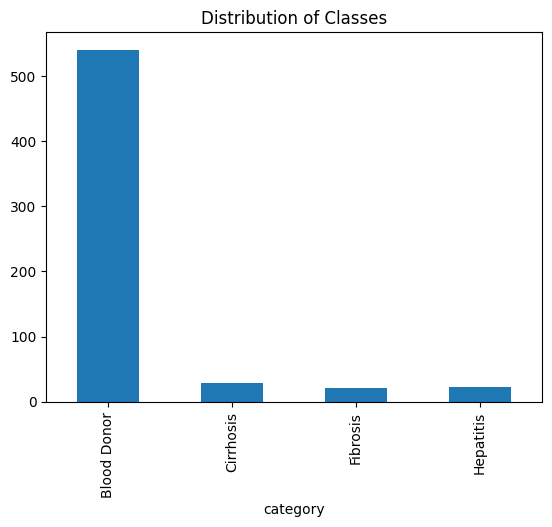

In [ ]:
# Graph (i.e. bar graph) the distribution of the classes
plot = heptatitis.groupby('category').size().plot(kind='bar', title='Distribution of Classes')

### Check for missing values

In [ ]:
heptatitis.isnull().sum()

,0
category,0
age,13
gender,19
ALB,0
ALP,16
ALT,0
AST,0
BIL,0
CHE,0
CHOL,8


#### Use the SimpleImputer to replace missing values

In [ ]:
#since SimpleImputer works differently in case of numeric and categorical columns, we will make sure that the columns with missing values are numeric dtypes
heptatitis.dtypes

,0
category,object
age,float64
gender,object
ALB,float64
ALP,float64
ALT,float64
AST,float64
BIL,float64
CHE,float64
CHOL,float64


In [ ]:
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
cols_to_impute_1 = ['age', 'ALP', 'CHOL']
heptatitis[cols_to_impute_1] = imp_mean.fit_transform(heptatitis[cols_to_impute_1])


imp_most_freq = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
cols_to_impute_2 = ['gender']
heptatitis[cols_to_impute_2] = imp_most_freq.fit_transform(heptatitis[cols_to_impute_2])


### Recheck missing values

In [ ]:
heptatitis.isnull().sum()

,0
category,0
age,0
gender,0
ALB,0
ALP,0
ALT,0
AST,0
BIL,0
CHE,0
CHOL,0


### Generate one-hot encodings for 'gender' column

In [ ]:
# Generate encodings for 'gender'
heptatitis['gender'].unique()

array(['m', 'f'], dtype=object)

In [ ]:
heptatitis = pd.get_dummies(heptatitis, columns=['gender'], dtype=int)
heptatitis.head()

,category,age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,gender_f,gender_m
0,Blood Donor,32.0,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0,0,1
1,Blood Donor,32.0,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5,0,1
2,Blood Donor,32.0,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3,0,1
3,Blood Donor,32.0,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7,0,1
4,Blood Donor,32.0,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7,0,1


### Encode labels

In [ ]:
# Encode 'category' column
le = LabelEncoder()
heptatitis['category']= le.fit_transform(heptatitis['category'])
heptatitis.head()

,category,age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,gender_f,gender_m
0,0,32.0,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0,0,1
1,0,32.0,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5,0,1
2,0,32.0,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3,0,1
3,0,32.0,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7,0,1
4,0,32.0,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7,0,1


In [ ]:
# since all the classes in the category displays the same values, lets do a sample() to cross check
heptatitis.sample(10)

,category,age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,gender_f,gender_m
322,0,33.000000,36.0,77.5,14.8,22.0,4.4,8.61,5.26,66.0,13.1,66.1,1,0
472,0,52.000000,38.2,70.3,19.5,17.5,2.7,10.02,6.17,65.0,35.5,71.1,1,0
600,1,47.328881,39.0,102.9,27.3,143.2,15.0,5.38,4.88,72.3,400.3,73.4,0,1
483,0,47.328881,26.2,72.9,28.5,28.8,5.5,7.49,4.91,58.0,27.6,57.0,0,1
231,0,53.000000,44.8,119.7,29.2,20.7,6.0,13.80,8.78,64.0,49.3,75.4,0,1
520,0,61.000000,38.1,66.4,11.8,22.7,6.8,6.35,6.55,65.0,14.5,78.9,1,0
314,0,71.000000,39.0,87.9,26.1,32.1,12.2,10.30,6.31,90.0,99.7,69.8,0,1
490,0,55.000000,39.9,83.6,18.4,27.4,8.0,8.43,7.67,73.0,13.6,73.3,1,0
404,0,45.000000,37.0,78.2,19.9,19.1,4.3,6.60,4.73,64.0,31.8,69.6,1,0
333,0,33.000000,41.2,73.1,14.3,20.8,11.1,7.40,3.22,56.0,11.4,69.9,1,0


In [ ]:
le.classes_

array(['Blood Donor', 'Cirrhosis', 'Fibrosis', 'Hepatitis'], dtype=object)

In [ ]:
le.transform(list(le.classes_))

array([0, 1, 2, 3])

### Display the correlation matrix for all variables

In [ ]:
heptatitis

,category,age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,gender_f,gender_m
0,0,32.0,38.5,52.500000,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0,0,1
1,0,32.0,38.5,70.300000,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5,0,1
2,0,32.0,46.9,74.700000,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3,0,1
3,0,32.0,43.2,52.000000,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7,0,1
4,0,32.0,39.2,74.100000,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
607,1,62.0,32.0,416.600000,5.9,110.3,50.0,5.57,6.30,55.7,650.9,68.5,1,0
608,1,64.0,24.0,102.800000,2.9,44.4,20.0,1.54,3.02,63.0,35.9,71.3,1,0
609,1,64.0,29.0,87.300000,3.5,99.0,48.0,1.66,3.63,66.7,64.2,82.0,1,0
610,1,46.0,33.0,68.304027,39.0,62.0,20.0,3.56,4.20,52.0,50.0,71.0,1,0


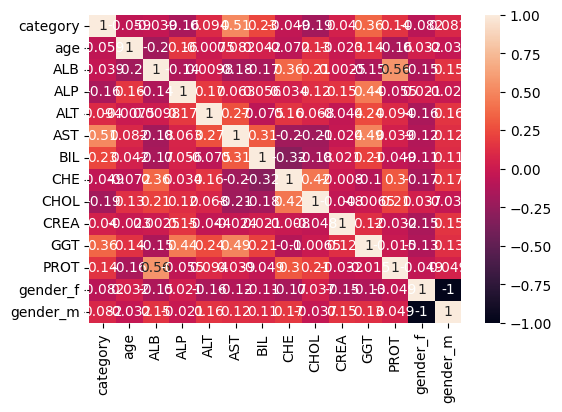

In [ ]:
# displaying the corr matrix
plt.figure(figsize=(6,4))
sns.heatmap(heptatitis.corr(), annot=True)
plt.show()

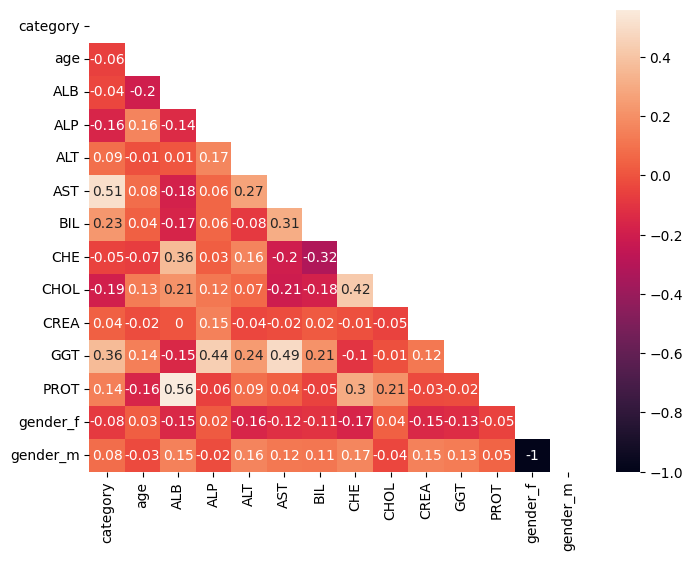

In [ ]:
# lets make this more neat by displaying only lower part, increasing the fiz size and rounding numbers to 2 dp
plt.figure(figsize=(8,6))
# Calculate the linear relationships between the variables
correlation_matrix = heptatitis.corr(numeric_only=True).round(2)
# Display only relevant portion of matrix
mask = np.zeros_like(correlation_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(correlation_matrix, annot = True, mask=mask)
plt.show()

### Display the first few rows of updated dataframe

In [ ]:
heptatitis.head(5)

,category,age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,gender_f,gender_m
0,0,32.0,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0,0,1
1,0,32.0,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5,0,1
2,0,32.0,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3,0,1
3,0,32.0,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7,0,1
4,0,32.0,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7,0,1


### Standardize independent variables

In [ ]:
# lets start by dropping the dependent variable
hep2 = heptatitis.drop(columns=['category'], axis=1)

In [ ]:
hep2.dtypes

,0
age,float64
ALB,float64
ALP,float64
ALT,float64
AST,float64
BIL,float64
CHE,float64
CHOL,float64
CREA,float64
GGT,float64


In [ ]:
# standardizing the remaining columns
scaler = StandardScaler()
columns_to_standardize = hep2.select_dtypes(include=['float64', 'int']).columns.tolist()  # Select numerical columns
hep2[columns_to_standardize] = scaler.fit_transform(hep2[columns_to_standardize])

### NOTE: Final dataframe must be ready for model training (i.e. all numeric and scaled values)

### Display a sample of 25 rows from the final updated dataframe

In [ ]:
hep2.sample(25)

,age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,gender_f,gender_m
406,-1.336876e-01,1.250601,-7.803464e-02,-0.340948,-0.334402,-0.392416,1.078444,0.455949,-0.065405,-0.276832,0.065422,1.279817,-1.279817
369,-7.372973e-01,0.271109,-1.008675e+00,-0.498119,-0.334402,-0.076372,-0.294985,1.220386,0.135327,-0.509729,0.213918,1.279817,-1.279817
323,-1.441509e+00,-0.830819,-6.465429e-01,-0.431321,-0.382910,-0.158309,-0.550506,-0.308489,-0.587310,-0.370358,-0.008826,1.279817,-1.279817
155,-7.148175e-16,0.236128,-1.063189e+00,-0.521694,-0.422323,-0.345595,-0.153535,-0.015158,0.055034,-0.438210,0.213918,-0.781362,0.781362
37,-1.240305e+00,1.233110,1.711744e-01,-0.168060,-0.110050,1.995477,0.544586,-1.392923,0.175474,-0.353853,0.696531,-0.781362,0.781362
31,-1.340907e+00,0.778346,8.940271e-02,0.291665,-0.140368,-0.199278,-0.231104,-1.037371,0.235693,-0.458382,1.234830,-0.781362,0.781362
157,-1.336876e-01,1.408020,-7.828291e-01,-0.663148,-0.516308,0.011418,-0.669141,-1.472923,0.496645,-0.526234,0.585159,-0.781362,0.781362
608,1.677142e+00,-3.087149,1.343236e+00,-1.001066,0.296207,0.526454,-3.041842,-2.086250,-0.366504,-0.062273,-0.138760,1.279817,-1.279817
611,1.174133e+00,-0.988237,-5.533553e-16,2.814258,1.375518,0.058240,0.394011,-0.059602,-0.286211,-0.097116,-0.751307,1.279817,-1.279817
458,3.693205e-01,-0.043727,2.671053e+00,0.189504,-0.443545,-0.351448,0.941557,0.775946,-0.085479,1.236086,0.028298,1.279817,-1.279817
